In [1]:
import pandas as pd 
import numpy as np 
from tqdm import tqdm

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import random
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/EDA/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import csr_matrix, issparse


In [3]:
complex_thetas = [0.1,0.2,0.3,0.4,0.5]
complex_thetas = [0.3] 
complex_thetas = [0.1] 

# complex_thetas = [0.3] 

simple_beta = [0.02,0.03,0.04,0.05] 

percentile_ths = [10,20,30,40,50,60,70,80,90]

In [5]:
def percentile_threshold(arr, percent):
    """
    Returns integer K such that at most `percent`% of non-NaN values 
    in arr are less than or equal to K.

    Parameters
    ----------
    arr : np.ndarray
        Input array of integers or NaN.
    percent : float
        Desired percentile (0–100).

    Returns
    -------
    int
        The integer K corresponding to that percentile.
    """
    # Filter out NaN values
    valid = arr[~np.isnan(arr)]
    
    if len(valid) == 0:
        return np.nan
    
    # Compute percentile
    K = np.percentile(valid, percent, interpolation='linear')
    
    # Ensure integer output (since input elements are integers)
    return int(np.floor(K))


In [7]:
complex_thetas = [0.5] 
all_simple = pd.DataFrame()
all_complex = pd.DataFrame()
all_adoption_type = pd.DataFrame()

nodes_list = [str(i) for i in range(400)]

for seed in tqdm(range(10)):
    for counter_p_small_world in range(1,6):
        
        p_small_world = counter_p_small_world*0.1
        p_small_world = np.round(p_small_world,3)
        #network name set
        network_name = f'smallworld_p0.{counter_p_small_world}_seed{seed}'

        complex_c = pd.DataFrame()
        complex_adoption_type_c = pd.DataFrame()
        #load data sets
        for theta in complex_thetas:
            df_curr_theta = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_EPH-v3.csv")
            df_curr_theta["th"] = theta
            df_curr_theta_adoption_type = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_adoption_type.csv")
            df_curr_theta_adoption_type["th"] = theta
            complex_c = pd.concat([complex_c,df_curr_theta])
            complex_adoption_type_c = pd.concat([complex_adoption_type_c,df_curr_theta_adoption_type])
        all_complex = pd.concat([complex_c,all_complex])
        all_adoption_type = pd.concat([complex_adoption_type_c,all_adoption_type])

100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 13.41it/s]


In [9]:
all_adoption_type

,0,1,2,3,4,5,6,7,8,9,...,394,395,396,397,398,399,seed,complex_param,simple_infection_ratio,th
0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0,0.5,0.524590,0.5
1,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,1,0.5,0.581897,0.5
2,1.0,NaN,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,1.0,1.0,2,0.5,0.696517,0.5
3,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,3,0.5,0.536885,0.5
4,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,NaN,...,NaN,1.0,0.0,NaN,1.0,1.0,4,0.5,0.587234,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,1.0,195,0.5,0.560185,0.5
196,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,196,0.5,0.511013,0.5
197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,NaN,NaN,197,0.5,0.479167,0.5
198,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,198,0.5,0.495614,0.5


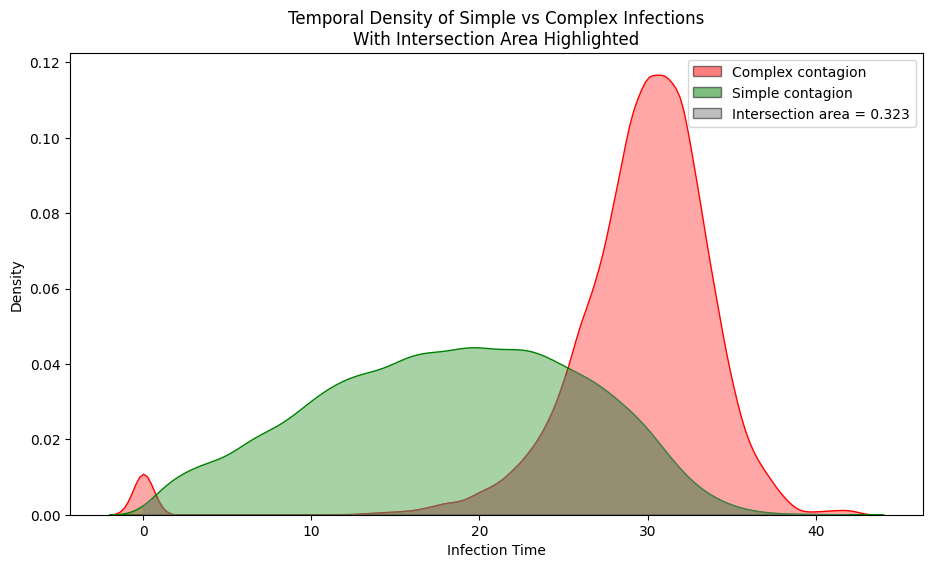

In [768]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

# -------------------------
# Extract data
# -------------------------
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta = df_curr_theta[node_cols].to_numpy()
adopt = df_curr_theta_adoption_type[node_cols].to_numpy()

theta_flat = theta.flatten()
adopt_flat = adopt.flatten()

# -------------------------
# CLEAN DATA
# -------------------------
mask_valid = np.isfinite(theta_flat)
theta_flat = theta_flat[mask_valid]
adopt_flat = adopt_flat[mask_valid]

complex_times = theta_flat[adopt_flat == 1]
simple_times  = theta_flat[adopt_flat == 0]

if len(complex_times) < 2 or len(simple_times) < 2:
    raise ValueError("Not enough valid simple/complex samples for KDE.")

# -------------------------
# KDE FIT
# -------------------------
kde_complex = gaussian_kde(complex_times)
kde_simple  = gaussian_kde(simple_times)

t_min, t_max = theta_flat.min(), theta_flat.max()
grid = np.linspace(t_min, t_max, 100)

f_complex = kde_complex(grid)
f_simple  = kde_simple(grid)

# Normalize to integrate to 1
f_complex /= np.trapz(f_complex, grid)
f_simple  /= np.trapz(f_simple, grid)

# Overlap area
intersection = np.minimum(f_complex, f_simple)
overlap_area = np.trapz(intersection, grid)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(11, 6))

# Draw KDEs
sns.kdeplot(x=theta_flat[adopt_flat==1], fill=True, alpha=0.35,
            color="red", label=None)
sns.kdeplot(x=theta_flat[adopt_flat==0], fill=True, alpha=0.35,
            color="green", label=None)

# Draw intersection region
plt.fill_between(grid, intersection, color="gray", alpha=0.4)

plt.xlabel("Infection Time")
plt.ylabel("Density")
plt.title("Temporal Density of Simple vs Complex Infections\nWith Intersection Area Highlighted")

# -------------------------
# CUSTOM LEGEND WITH COLOR PATCHES
# -------------------------
legend_elements = [
    Patch(facecolor="red",  edgecolor="black", alpha=0.5, label="Complex contagion"),
    Patch(facecolor="green", edgecolor="black", alpha=0.5, label="Simple contagion"),
    Patch(facecolor="gray",  edgecolor="black", alpha=0.5, label=f"Intersection area = {overlap_area:.3f}")
]

plt.legend(handles=legend_elements, loc="upper right")

plt.show()


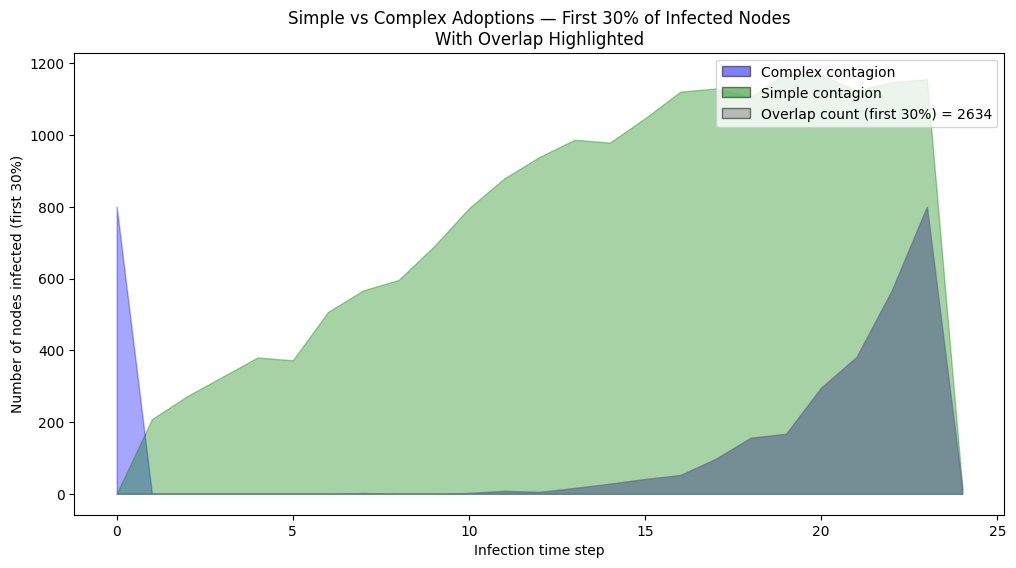

In [771]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------
# Extract data
# -------------------------
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta = df_curr_theta[node_cols].to_numpy()               # infection times
adopt = df_curr_theta_adoption_type[node_cols].to_numpy() # 0 simple, 1 complex

theta_flat = theta.flatten()
adopt_flat = adopt.flatten()

# CLEAN invalid values
mask_valid = np.isfinite(theta_flat)
theta_flat = theta_flat[mask_valid]
adopt_flat = adopt_flat[mask_valid]

# -------------------------
# 1. Determine early 30% cutoff based on number of infected nodes
# -------------------------
N = len(theta_flat)
k30 = int(0.30 * N)   # number of nodes to keep

# sort nodes by infection time
order = np.argsort(theta_flat)
early_idx = order[:k30]    # only the first 30% infected nodes

# extract early 30% times & types
theta_early = theta_flat[early_idx]
adopt_early = adopt_flat[early_idx]

complex_times = theta_early[adopt_early == 1]
simple_times  = theta_early[adopt_early == 0]

# -------------------------
# 2. Histogram of raw counts
# -------------------------
max_step = int(theta_early.max())
bins = np.arange(0, max_step + 2)

complex_counts, _ = np.histogram(complex_times, bins=bins)
simple_counts,  _ = np.histogram(simple_times,  bins=bins)

x = bins[:-1]  # time values

# -------------------------
# 3. Intersection counts
# -------------------------
intersection = np.minimum(complex_counts, simple_counts)
overlap_raw_count = intersection.sum()  # total overlapping node count

# -------------------------
# 4. Plot
# -------------------------
plt.figure(figsize=(12, 6))

plt.fill_between(x, complex_counts, alpha=0.35, color="blue")
plt.fill_between(x, simple_counts,  alpha=0.35, color="green")
plt.fill_between(x, intersection,   alpha=0.45, color="gray")

plt.xlabel("Infection time step")
plt.ylabel("Number of nodes infected (first 30%)")
plt.title("Simple vs Complex Adoptions — First 30% of Infected Nodes\nWith Overlap Highlighted")

# Legend
legend_elements = [
    Patch(facecolor="blue",  edgecolor="black", alpha=0.5, label="Complex contagion"),
    Patch(facecolor="green", edgecolor="black", alpha=0.5, label="Simple contagion"),
    Patch(facecolor="gray",  edgecolor="black", alpha=0.5, 
          label=f"Overlap count (first 30%) = {overlap_raw_count}")
]

plt.legend(handles=legend_elements, loc="upper right")
plt.show()


In [773]:
# Calculate histogram counts for each timestep
max_step = int(theta_flat.max())
steps = np.arange(max_step + 1)

complex_times = theta_flat[adopt_flat == 1]
simple_times  = theta_flat[adopt_flat == 0]

complex_hist, _ = np.histogram(complex_times, bins=steps)
simple_hist, _  = np.histogram(simple_times,  bins=steps)

# convert to probabilities per time bucket
total = complex_hist + simple_hist
pc = np.divide(complex_hist, total, out=np.zeros_like(complex_hist, dtype=float), where=total>0)
ps = np.divide(simple_hist, total, out=np.zeros_like(simple_hist, dtype=float), where=total>0)

# Temporal Mixing Index
TMI = np.mean(np.abs(pc - ps))
print("Temporal Mixing Index (0=mixed, 1=separated):", TMI)


Temporal Mixing Index (0=mixed, 1=separated): 0.8057835961272785


In [775]:
from scipy.stats import wasserstein_distance

emd = wasserstein_distance(complex_times, simple_times)
print("Earth Mover Distance between timelines:", emd)


Earth Mover Distance between timelines: 11.114432702350399


# 30 
2. th=0.1 --> 1039 node
3. th=0.2 --> 3054 node
4. th=0.3 --> 4891 node
5. th=0.4 --> 4921 node
6. th=0.5 --> 2634 node

## Experimental evidence showing that having simple and complex contagion simutanousely then we will have higher generators. distribution of generators of EPH instead of just its average a long time. 

1. th=0.1 --> Earth Mover Distance between timelines: 1.2711785604408736
2. th=0.2 --> Earth Mover Distance between timelines: 3.410858193280841
3. th=0.3 --> Earth Mover Distance between timelines: 5.920487041721606
4. th=0.4 --> Earth Mover Distance between timelines: 8.474005239184107
5. th=0.5 --> Earth Mover Distance between timelines: 11.114432702350399

1. th=0.1 --> Temporal Mixing Index (0=mixed, 1=separated): 0.894360272615513
2. th=0.2 --> Temporal Mixing Index (0=mixed, 1=separated): 0.770493586313251
3. th=0.3 --> Temporal Mixing Index (0=mixed, 1=separated): 0.7780132502871644
4. th=0.4 --> Temporal Mixing Index (0=mixed, 1=separated): 0.8119496416388082
5. th=0.5 --> Temporal Mixing Index (0=mixed, 1=separated): 0.8057835961272785

In [488]:
# counter_p_small_world = 3
# seed = 0
# theta = 0.4
# network_name = f'smallworld_p0.{counter_p_small_world}_seed{seed}'
# df_curr_theta = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_EPH-v3.csv")
# df_curr_theta_adoption_type = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_adoption_type.csv")
df_curr_theta = all_complex.copy()
df_curr_theta_adoption_type = all_adoption_type.copy()

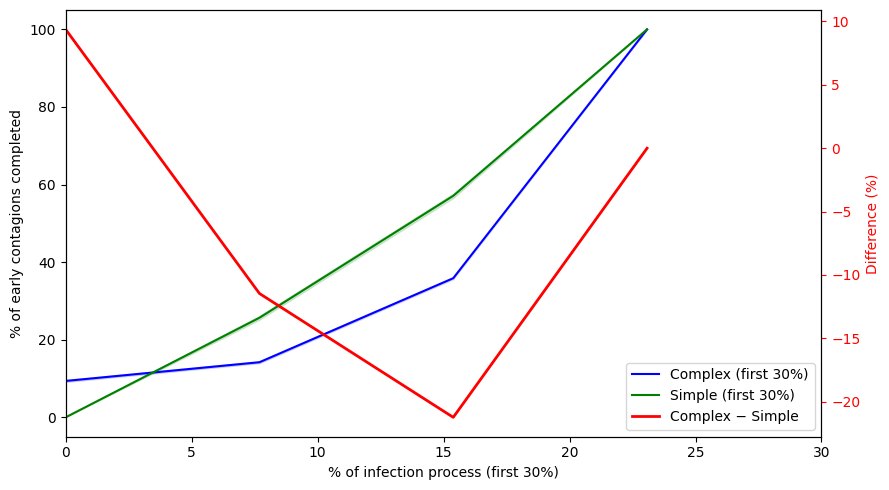

In [489]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Select node columns
# -------------------------
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta = df_curr_theta[node_cols].to_numpy().astype(int)
adopt_type = df_curr_theta_adoption_type[node_cols].to_numpy()
n_sims, n_nodes = theta.shape

max_step = theta.max()
steps = np.arange(0, max_step + 1)
steps_pct = steps / max_step * 100.0  

# -------------------------
# 2. Determine cutoff and mask infections
# -------------------------
cutoff_pct = 30.0                          # parameter
cutoff_step = cutoff_pct / 100 * max_step  # step threshold

early_mask = (theta <= cutoff_step)

theta_early = theta.copy()
theta_early[~early_mask] = max_step + 99999

# -------------------------
# 3. Recompute cumulative infections
# -------------------------
infected = theta_early[:, None, :] <= steps[None, :, None]

complex_mask = (adopt_type == 1)[:, None, :]
simple_mask  = (adopt_type == 0)[:, None, :]

complex_counts = (infected & complex_mask).sum(axis=2)
simple_counts  = (infected & simple_mask).sum(axis=2)

total_complex = (complex_mask & early_mask[:, None, :]).sum(axis=2)[:, 0]
total_simple  = (simple_mask  & early_mask[:, None, :]).sum(axis=2)[:, 0]

total_complex_safe = np.where(total_complex == 0, np.nan, total_complex)
total_simple_safe  = np.where(total_simple  == 0, np.nan, total_simple)

# -------------------------
# 4. Fraction completed
# -------------------------
frac_complex = complex_counts / total_complex_safe[:, None] * 100.0
frac_simple  = simple_counts  / total_simple_safe[:,  None] * 100.0

# -------------------------
# 5. Mean + 95% z-CI
# -------------------------
z = 1.96

def mean_ci(arr):
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0, ddof=1)
    n = np.sum(~np.isnan(arr), axis=0)
    se = std / np.sqrt(n)
    lo = mean - z * se
    hi = mean + z * se
    return mean, np.clip(lo, 0, 100), np.clip(hi, 0, 100)

mean_complex, low_complex, high_complex = mean_ci(frac_complex)
mean_simple,  low_simple,  high_simple  = mean_ci(frac_simple)

difference = mean_complex - mean_simple

# -------------------------
# 6. Keep only first 30% of timeline
# -------------------------
mask_first30 = steps_pct <= cutoff_pct

steps_pct_30   = steps_pct[mask_first30]
mean_complex30 = mean_complex[mask_first30]
low_complex30  = low_complex[mask_first30]
high_complex30 = high_complex[mask_first30]

mean_simple30  = mean_simple[mask_first30]
low_simple30   = low_simple[mask_first30]
high_simple30  = high_simple[mask_first30]

difference30   = difference[mask_first30]

# -------------------------
# 7. Plot (only first 30%)
# -------------------------
fig, ax_left = plt.subplots(figsize=(9, 5))
ax_right = ax_left.twinx()

# Complex
ax_left.plot(steps_pct_30, mean_complex30, label="Complex (first 30%)", color="blue")
ax_left.fill_between(steps_pct_30, low_complex30, high_complex30, alpha=0.15, color="blue")

# Simple
ax_left.plot(steps_pct_30, mean_simple30, label="Simple (first 30%)", color="green")
ax_left.fill_between(steps_pct_30, low_simple30, high_simple30, alpha=0.15, color="green")

ax_left.set_xlabel("% of infection process (first 30%)")
ax_left.set_ylabel("% of early contagions completed")
ax_left.set_xlim(0, cutoff_pct)

# Difference
ax_right.plot(steps_pct_30, difference30, color='red', linewidth=2, label="Complex − Simple")
ax_right.set_ylabel("Difference (%)", color='red')
ax_right.tick_params(axis='y', colors='red')

# Legend
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()


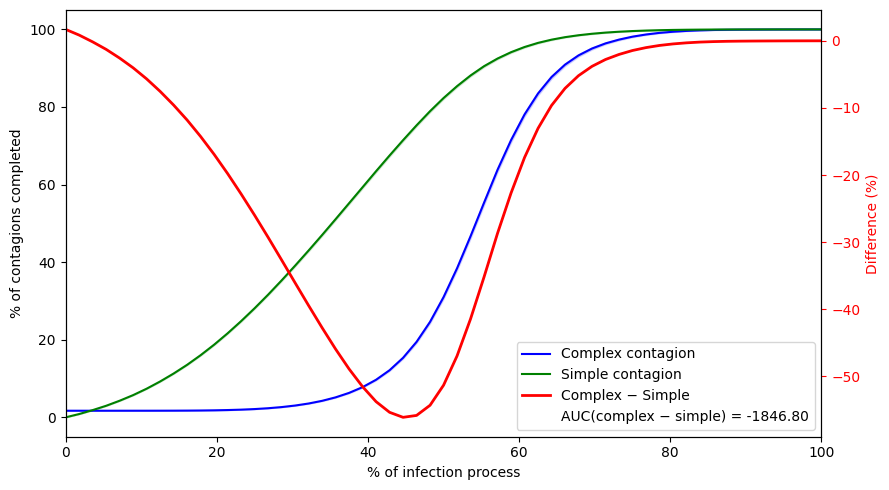

In [459]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Select node columns
# -------------------------
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta = df_curr_theta[node_cols].to_numpy().astype(int)          
adopt_type = df_curr_theta_adoption_type[node_cols].to_numpy()
n_sims, n_nodes = theta.shape

max_step = theta.max()
steps = np.arange(0, max_step + 1)
steps_pct = steps / max_step * 100.0  

# -------------------------
# 2. Cumulative infections
# -------------------------
infected = theta[:, None, :] <= steps[None, :, None]             

complex_mask = (adopt_type == 1)[:, None, :]
simple_mask  = (adopt_type == 0)[:, None, :]

complex_counts = (infected & complex_mask).sum(axis=2)
simple_counts  = (infected & simple_mask).sum(axis=2)

total_complex = complex_mask.sum(axis=2)[:, 0]
total_simple  = simple_mask.sum(axis=2)[:, 0]

total_complex_safe = np.where(total_complex == 0, np.nan, total_complex)
total_simple_safe  = np.where(total_simple  == 0, np.nan, total_simple)

# -------------------------
# 3. Fractions (0–100% of that type)
# -------------------------
frac_complex = complex_counts / total_complex_safe[:, None] * 100.0
frac_simple  =  simple_counts / total_simple_safe[:, None] * 100.0

# -------------------------
# 4. Means + CI
# -------------------------
z = 1.96

def mean_ci(arr):
    mean = np.nanmean(arr, axis=0)
    std  = np.nanstd(arr, axis=0, ddof=1)
    n    = np.sum(~np.isnan(arr), axis=0)
    se   = std / np.sqrt(n)
    lo   = mean - z * se
    hi   = mean + z * se
    return mean, np.clip(lo, 0, 100), np.clip(hi, 0, 100)

mean_complex, low_complex, high_complex = mean_ci(frac_complex)
mean_simple,  low_simple,  high_simple  = mean_ci(frac_simple)

# -------------------------
# 5. Difference curve + AREA UNDER CURVE
# -------------------------
difference = mean_complex - mean_simple

# Area under blue minus green
AUC_diff = np.trapz(difference, steps_pct)

# -------------------------
# 6. Plot
# -------------------------
fig, ax_left = plt.subplots(figsize=(9, 5))
ax_right = ax_left.twinx()

# ---- Left axis curves ----
ax_left.plot(steps_pct, mean_complex, color="blue", label="Complex contagion")
ax_left.fill_between(steps_pct, low_complex, high_complex, color="blue", alpha=0.15)

ax_left.plot(steps_pct, mean_simple, color="green", label="Simple contagion")
ax_left.fill_between(steps_pct, low_simple, high_simple, color="green", alpha=0.15)

ax_left.set_xlabel("% of infection process")
ax_left.set_ylabel("% of contagions completed")
ax_left.set_xlim(0, 100)

# ---- Right axis difference ----
ax_right.plot(steps_pct, difference, color="red", linewidth=2,
              label="Complex − Simple")
ax_right.set_ylabel("Difference (%)", color="red")
ax_right.tick_params(axis='y', colors='red')

# ---- Legend with AUC shown ----
auc_label = f"AUC(complex − simple) = {AUC_diff:.2f}"

lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()

# Add AUC text as a dummy legend entry
from matplotlib.lines import Line2D
dummy = Line2D([], [], color="white", label=auc_label)  # invisible entry

ax_left.legend(
    lines1 + lines2 + [dummy],
    labels1 + labels2 + [auc_label],
    loc="lower right"
)

plt.tight_layout()
plt.show()


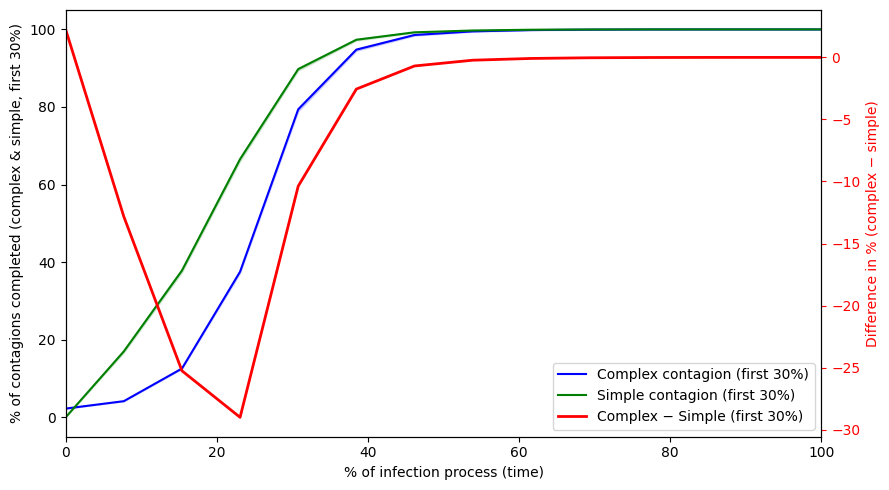

In [384]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0. Parameters
# -------------------------------------------------
INITIAL_FRACTION = 0.5  # first 30% of infections

# -------------------------------------------------
# 1. Select node columns
# -------------------------------------------------
# Assumes df_curr_theta and df_curr_theta_adoption_type are already defined
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta_full = df_curr_theta[node_cols].to_numpy().astype(int)        # (n_sims, n_nodes_full)
adopt_type_full = df_curr_theta_adoption_type[node_cols].to_numpy() # (n_sims, n_nodes_full)
n_sims, n_nodes_full = theta_full.shape

# Time axis (based on all nodes)
max_step = theta_full.max()
steps = np.arange(0, max_step + 1)
steps_pct = steps / max_step * 100.0  # x-axis in % of process

# -------------------------------------------------
# 2. Restrict to first 30% of infections (per sim)
# -------------------------------------------------
k = int(np.floor(INITIAL_FRACTION * n_nodes_full))
if k < 1:
    raise ValueError("INITIAL_FRACTION is too small, results in zero nodes.")

# sort nodes by infection time within each simulation
sort_idx = np.argsort(theta_full, axis=1)             # (n_sims, n_nodes_full)
rows = np.arange(n_sims)[:, None]                     # (n_sims, 1)
sel_idx = sort_idx[:, :k]                             # (n_sims, k)

# take only earliest 30% infected nodes
theta = theta_full[rows, sel_idx]                     # (n_sims, k)
adopt_type = adopt_type_full[rows, sel_idx]           # (n_sims, k)
n_sims, n_nodes = theta.shape                         # n_nodes == k

# -------------------------------------------------
# 3. Cumulative infections on this subset
# -------------------------------------------------
# infected[s, t, i] = node i in sim s is infected (within subset) by step t
infected = theta[:, None, :] <= steps[None, :, None]   # (n_sims, n_steps, n_nodes)

complex_mask = (adopt_type == 1)[:, None, :]           # (n_sims, 1, n_nodes)
simple_mask  = (adopt_type == 0)[:, None, :]

complex_counts = (infected & complex_mask).sum(axis=2) # (n_sims, n_steps)
simple_counts  = (infected & simple_mask).sum(axis=2)

# totals of each type *within this subset* per simulation
total_complex = complex_mask.sum(axis=2)[:, 0]         # (n_sims,)
total_simple  = simple_mask.sum(axis=2)[:, 0]

# avoid division by zero
total_complex_safe = np.where(total_complex == 0, np.nan, total_complex)
total_simple_safe  = np.where(total_simple  == 0, np.nan, total_simple)

# -------------------------------------------------
# 4. Fractions of each type (0–100% of that type, in the subset)
# -------------------------------------------------
frac_complex = complex_counts / total_complex_safe[:, None] * 100.0
frac_simple  = simple_counts  / total_simple_safe[:,  None] * 100.0

# -------------------------------------------------
# 5. Mean + 95% z-score CI
# -------------------------------------------------
z = 1.96

def mean_ci(arr):
    """
    arr: (n_sims, n_steps)
    returns: mean, low, high (length n_steps each)
    """
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0, ddof=1)
    n = np.sum(~np.isnan(arr), axis=0)
    se = std / np.sqrt(n)
    lo = mean - z * se
    hi = mean + z * se
    return mean, np.clip(lo, 0, 100), np.clip(hi, 0, 100)

mean_complex, low_complex, high_complex = mean_ci(frac_complex)
mean_simple,  low_simple,  high_simple  = mean_ci(frac_simple)

# -------------------------------------------------
# 6. Difference curve (right axis)
# -------------------------------------------------
difference = mean_complex - mean_simple  # percentage points: complex − simple

# -------------------------------------------------
# 7. Plot
# -------------------------------------------------
fig, ax_left = plt.subplots(figsize=(9, 5))

# Right y-axis
ax_right = ax_left.twinx()

# ---- Left axis: complex & simple contagion ----
ax_left.plot(steps_pct, mean_complex, label="Complex contagion (first 30%)", color="blue")
ax_left.fill_between(steps_pct, low_complex, high_complex, alpha=0.15, color="blue")

ax_left.plot(steps_pct, mean_simple, label="Simple contagion (first 30%)", color="green")
ax_left.fill_between(steps_pct, low_simple, high_simple, alpha=0.15, color="green")

ax_left.set_xlabel("% of infection process (time)")
ax_left.set_ylabel("% of contagions completed (complex & simple, first 30%)")
ax_left.set_xlim(0, 100)

# ---- Right axis: difference ----
ax_right.plot(steps_pct, difference, label="Complex − Simple (first 30%)", color="red", linewidth=2)
ax_right.set_ylabel("Difference in % (complex − simple)", color="red")
ax_right.tick_params(axis='y', colors='red')

# ---- Legend ----
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()


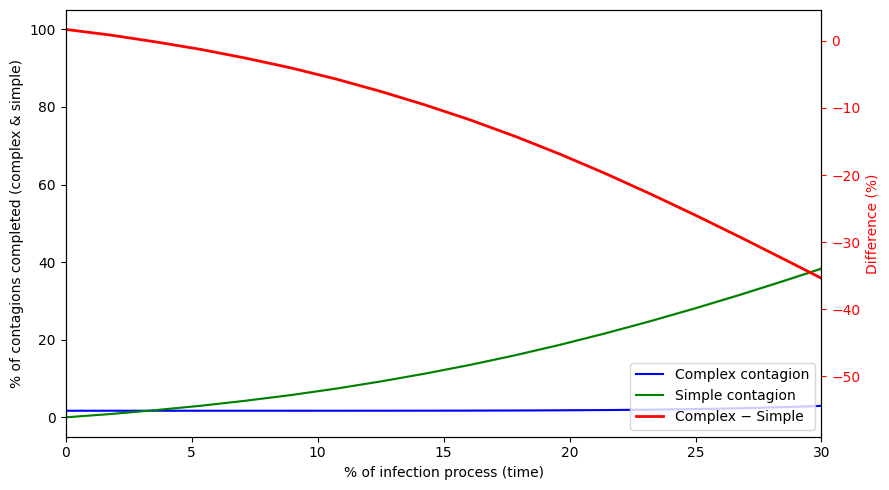

In [372]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Select node columns
# -------------------------
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta = df_curr_theta[node_cols].to_numpy().astype(int)
adopt_type = df_curr_theta_adoption_type[node_cols].to_numpy()
n_sims, n_nodes = theta.shape

max_step = theta.max()
steps = np.arange(0, max_step + 1)
steps_pct = steps / max_step * 100.0  # x-axis in %

# -------------------------
# 2. Cumulative infections
# -------------------------
infected = theta[:, None, :] <= steps[None, :, None]

complex_mask = (adopt_type == 1)[:, None, :]
simple_mask  = (adopt_type == 0)[:, None, :]

complex_counts = (infected & complex_mask).sum(axis=2)
simple_counts  = (infected & simple_mask).sum(axis=2)

total_complex = complex_mask.sum(axis=2)[:, 0]
total_simple  = simple_mask.sum(axis=2)[:, 0]

total_complex_safe = np.where(total_complex == 0, np.nan, total_complex)
total_simple_safe  = np.where(total_simple  == 0, np.nan, total_simple)

# -------------------------
# 3. Fractions of each type (0–100%)
# -------------------------
frac_complex = complex_counts / total_complex_safe[:, None] * 100
frac_simple  = simple_counts  / total_simple_safe[:,  None] * 100

# -------------------------
# 4. Mean + 95% z-score CI
# -------------------------
z = 1.96

def mean_ci(arr):
    mean = np.nanmean(arr, axis=0)
    std  = np.nanstd(arr, axis=0, ddof=1)
    n    = np.sum(~np.isnan(arr), axis=0)
    se   = std / np.sqrt(n)
    lo   = mean - z * se
    hi   = mean + z * se
    return mean, np.clip(lo, 0, 100), np.clip(hi, 0, 100)

mean_complex, low_complex, high_complex = mean_ci(frac_complex)
mean_simple,  low_simple,  high_simple  = mean_ci(frac_simple)

# -------------------------
# 5. Difference curve
# -------------------------
difference = mean_complex - mean_simple

# -------------------------
# 6. Plot (ONLY UP TO 30% of x-axis)
# -------------------------
x_limit_pct = 30  # show only first 30% of timeline

fig, ax_left = plt.subplots(figsize=(9, 5))
ax_right = ax_left.twinx()

# ---- Left axis ----
ax_left.plot(steps_pct, mean_complex, color="blue", label="Complex contagion")
ax_left.fill_between(steps_pct, low_complex, high_complex, alpha=0.15, color="blue")

ax_left.plot(steps_pct, mean_simple, color="green", label="Simple contagion")
ax_left.fill_between(steps_pct, low_simple, high_simple, alpha=0.15, color="green")

ax_left.set_xlabel("% of infection process (time)")
ax_left.set_ylabel("% of contagions completed (complex & simple)")
ax_left.set_xlim(0, x_limit_pct)    # <<< SHOW ONLY 0–30%

# ---- Right axis ----
ax_right.plot(steps_pct, difference, color="red", linewidth=2, label="Complex − Simple")
ax_right.set_ylabel("Difference (%)", color="red")
ax_right.tick_params(axis='y', colors='red')

# ---- Legend ----
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()


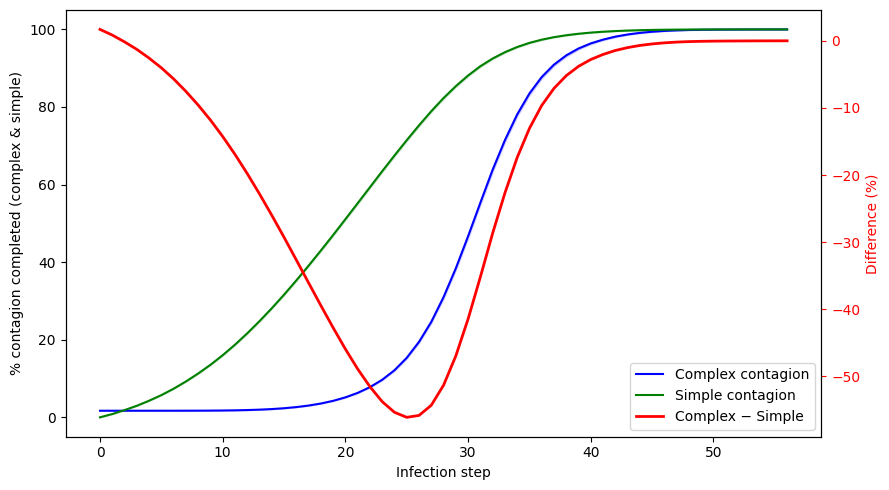

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Select node columns
# -------------------------
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta = df_curr_theta[node_cols].to_numpy().astype(int)
adopt_type = df_curr_theta_adoption_type[node_cols].to_numpy()
n_sims, n_nodes = theta.shape

max_step = theta.max()
steps = np.arange(0, max_step + 1)

# -------------------------
# 2. Cumulative infections
# -------------------------
infected = theta[:, None, :] <= steps[None, :, None]

complex_mask = (adopt_type == 1)[:, None, :]
simple_mask  = (adopt_type == 0)[:, None, :]

complex_counts = (infected & complex_mask).sum(axis=2)
simple_counts  = (infected & simple_mask).sum(axis=2)

total_complex = complex_mask.sum(axis=2)[:, 0]
total_simple  = simple_mask.sum(axis=2)[:, 0]

total_complex_safe = np.where(total_complex == 0, np.nan, total_complex)
total_simple_safe  = np.where(total_simple == 0, np.nan, total_simple)

# -------------------------
# 3. Fractions of each type
# -------------------------
frac_complex = complex_counts / total_complex_safe[:, None] * 100
frac_simple  = simple_counts  / total_simple_safe[:,  None] * 100

# -------------------------
# 4. Mean + 95% z-score CI
# -------------------------
z = 1.96

def mean_ci(arr):
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0, ddof=1)
    n = np.sum(~np.isnan(arr), axis=0)
    se = std / np.sqrt(n)
    lo = mean - z * se
    hi = mean + z * se
    return mean, np.clip(lo, 0, 100), np.clip(hi, 0, 100)

mean_complex, low_complex, high_complex = mean_ci(frac_complex)
mean_simple,  low_simple,  high_simple  = mean_ci(frac_simple)

# -------------------------
# 5. Difference curve (right axis)
# -------------------------
difference = mean_complex - mean_simple   # % complex − % simple

# -------------------------
# 6. Plot
# -------------------------
fig, ax_left = plt.subplots(figsize=(9, 5))

# Right y-axis
ax_right = ax_left.twinx()

# ---- Left axis plots ----
# Complex
ax_left.plot(steps, mean_complex, label="Complex contagion", color="blue")
ax_left.fill_between(steps, low_complex, high_complex, alpha=0.15, color="blue")

# Simple
ax_left.plot(steps, mean_simple, label="Simple contagion", color="green")
ax_left.fill_between(steps, low_simple, high_simple, alpha=0.15, color="green")

ax_left.set_xlabel("Infection step")
ax_left.set_ylabel("% contagion completed (complex & simple)")

# ---- Right axis plot ----
ax_right.plot(steps, difference, label="Complex − Simple", color="red", linewidth=2)
ax_right.set_ylabel("Difference (%)", color="red")
ax_right.tick_params(axis='y', colors='red')

# ---- Legend ----
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()


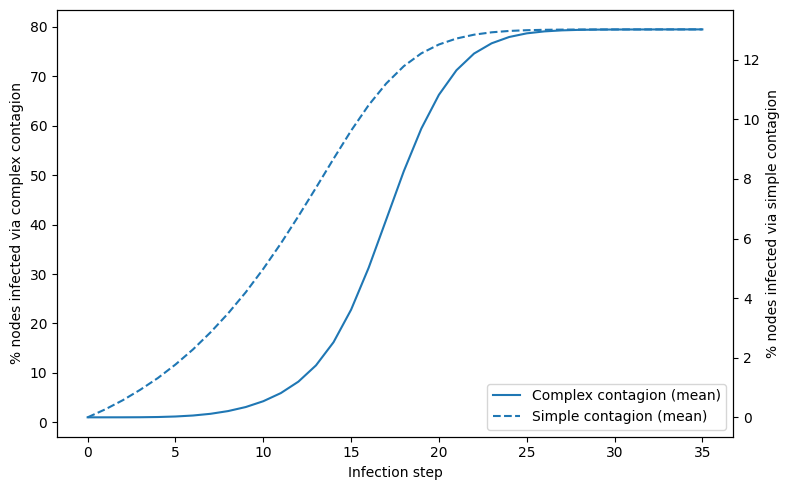

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Select node columns
# -------------------------
node_cols = [c for c in df_curr_theta.columns if str(c).isdigit()]
node_cols = sorted(node_cols, key=lambda x: int(x))

theta = df_curr_theta[node_cols].to_numpy().astype(int)          # (n_sims, n_nodes)
adopt_type = df_curr_theta_adoption_type[node_cols].to_numpy()   # (n_sims, n_nodes)
n_sims, n_nodes = theta.shape

# all possible time steps (integer)
max_step = theta.max()
steps = np.arange(0, max_step + 1)    # shape (n_steps,)

# -------------------------
# 2. Cumulative fractions
# -------------------------
# infected[s, t, i] = node i in sim s is infected by step t
infected = theta[:, None, :] <= steps[None, :, None]          # (n_sims, n_steps, n_nodes)

complex_mask = (adopt_type == 1)[:, None, :]                  # (n_sims, 1, n_nodes)
simple_mask  = (adopt_type == 0)[:, None, :]

complex_counts = (infected & complex_mask).sum(axis=2)        # (n_sims, n_steps)
simple_counts  = (infected & simple_mask).sum(axis=2)

# fraction of nodes (×100 to get percent)
frac_complex = complex_counts / n_nodes * 100.0               # (n_sims, n_steps)
frac_simple  = simple_counts  / n_nodes * 100.0

# -------------------------
# 3. Mean + 95% CI over sims
# -------------------------
mean_complex = frac_complex.mean(axis=0)
low_complex, high_complex = np.percentile(frac_complex, [2.5, 97.5], axis=0)

mean_simple = frac_simple.mean(axis=0)
low_simple, high_simple = np.percentile(frac_simple, [2.5, 97.5], axis=0)

# -------------------------
# 4. Plot (two y-axes)
# -------------------------
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

# Complex
ax1.plot(steps, mean_complex, label="Complex contagion (mean)")
# ax1.fill_between(steps, low_complex, high_complex, alpha=0.2)
ax1.set_xlabel("Infection step")
ax1.set_ylabel("% nodes infected via complex contagion")

# Simple
ax2.plot(steps, mean_simple, linestyle="--", label="Simple contagion (mean)")
# ax2.fill_between(steps, low_simple, high_simple, alpha=0.2)
ax2.set_ylabel("% nodes infected via simple contagion")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()


In [157]:
df_curr_theta_adoption_type

,0,1,2,3,4,5,6,7,8,9,...,394,395,396,397,398,399,seed,complex_param,simple_infection_ratio,th
0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0,0.1,0.013055,0.1
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1,0.1,0.015385,0.1
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,2,0.1,0.015385,0.1
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,3,0.1,0.005076,0.1
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,4,0.1,0.018229,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,195,0.1,0.010582,0.1
196,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,196,0.1,0.025070,0.1
197,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,197,0.1,0.013624,0.1
198,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,198,0.1,0.013928,0.1


In [22]:
all_simple = pd.DataFrame()
all_complex = pd.DataFrame()
all_adoption_type = pd.DataFrame()

nodes_list = [str(i) for i in range(400)]

for seed in tqdm(range(10)):
    for counter_p_small_world in range(1,6):
        
        p_small_world = counter_p_small_world*0.1
        p_small_world = np.round(p_small_world,3)
        print(p_small_world)
        print(seed)
        #network name set
        network_name = f'smallworld_p0.{counter_p_small_world}_seed{seed}'

        complex_c = pd.DataFrame()
        complex_adoption_type_c = pd.DataFrame()
        #load data sets
        for theta in complex_thetas:
            df_curr_theta = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_EPH-v3.csv")
            df_curr_theta["th"] = theta
            df_curr_theta_adoption_type = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_adoption_type.csv")
            df_curr_theta_adoption_type["th"] = theta
            complex_c = pd.concat([complex_c,df_curr_theta])
            complex_adoption_type_c = pd.concat([complex_adoption_type_c,df_curr_theta_adoption_type])
        all_complex = pd.concat([complex_c,all_complex])
        all_adoption_type = pd.concat([complex_adoption_type_c,all_adoption_type])

        simple_c = pd.DataFrame()
        for beta in simple_beta:
            df = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_simple_{network_name}_beta_{beta}_EPH-v3.csv")
            simple_c = pd.concat([simple_c,df])
        all_simple = pd.concat([simple_c,all_simple])


 10%|████▍                                       | 1/10 [00:00<00:01,  5.41it/s]

0.1
0
0.2
0
0.3
0
0.4
0
0.5
0
0.1
1


 20%|████████▊                                   | 2/10 [00:00<00:01,  5.49it/s]

0.2
1
0.3
1
0.4
1
0.5
1
0.1
2


 30%|█████████████▏                              | 3/10 [00:00<00:01,  4.89it/s]

...

0.3
7
0.4
7
0.5
7
0.1
8
0.2
8


 90%|███████████████████████████████████████▌    | 9/10 [00:02<00:00,  4.10it/s]

0.3
8
0.4
8
0.5
8
0.1
9
0.2
9
0.3
9
0.4
9


100%|███████████████████████████████████████████| 10/10 [00:02<00:00,  4.19it/s]

0.5
9


In [192]:
all_complex

,0,1,2,3,4,5,6,7,8,9,...,396,397,398,399,seed,complex_param,simple_infection_ratio,EPH,corr,th
0,5.0,5.0,5.0,5.0,5.0,NaN,5.0,4.0,4.0,5.0,...,5.0,4.0,5.0,4.0,0,0.1,0.013055,1.277618,-0.105405,0.1
1,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,4.0,3.0,0.0,3.0,1,0.1,0.015385,1.182741,-0.077954,0.1
2,3.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,...,4.0,4.0,4.0,4.0,2,0.1,0.015385,1.213007,-0.029042,0.1
3,5.0,4.0,5.0,5.0,4.0,5.0,5.0,4.0,4.0,5.0,...,5.0,4.0,4.0,4.0,3,0.1,0.005076,1.205951,-0.020405,0.1
4,3.0,4.0,2.0,1.0,3.0,4.0,0.0,3.0,3.0,4.0,...,3.0,2.0,4.0,3.0,4,0.1,0.018229,1.225535,-0.043508,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,6.0,6.0,5.0,6.0,5.0,6.0,6.0,7.0,6.0,6.0,...,6.0,4.0,6.0,6.0,195,0.1,0.010582,1.265584,-0.144582,0.1
196,4.0,4.0,4.0,4.0,4.0,0.0,4.0,3.0,4.0,4.0,...,5.0,5.0,3.0,4.0,196,0.1,0.025070,1.311688,-0.022089,0.1
197,7.0,7.0,6.0,7.0,6.0,6.0,6.0,6.0,5.0,6.0,...,7.0,6.0,7.0,7.0,197,0.1,0.013624,1.272924,-0.134736,0.1
198,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,2.0,2.0,3.0,3.0,198,0.1,0.013928,1.227876,-0.058914,0.1


In [193]:
infection_step = all_complex.iloc[0][nodes_list].values
percentile_threshold(infection_step,percent=10)

3

In [194]:
np.mean(adoption_type[infection_step <= percentile_threshold(infection_step,percent=10)] == 1)

0.6666666666666666

In [195]:
complex_edges = np.where(adoption_type[infection_step <= percentile_threshold(infection_step,percent=10)] == 1)[0]
complex_edges

array([ 0,  1,  4,  6,  7,  8, 12, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24,
       25, 26, 27, 32, 33, 34, 37, 38, 39, 40, 42, 43, 44])

In [201]:
simple_edges = np.where(adoption_type[infection_step <= percentile_threshold(infection_step,percent=10)] == 0)[0]
simple_edges

array([ 2,  5,  9, 10, 11, 13, 18, 29, 31, 35, 36, 41])

In [203]:
network_name
import networkx as nx

# Path to file (adjust if it's in another folder)
file_path = f"../networks/unweighted/G_unweighted_{network_name}.graphml"

# Load graph
G = nx.read_graphml(file_path)

print("✅ Graph loaded")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

✅ Graph loaded
Nodes: 400
Edges: 2800


In [205]:
(str(u),str(v))

('37', '37')

In [207]:
('0', '1') in G.edges()
sum = 0 
for u in simple_edges:
    for v in complex_edges:
        if (str(u),str(v)) in G.edges() or (str(v),str(u)) in G.edges():
            sum += 1
sum / (len(simple_edges) * len(complex_edges))

0.13333333333333333

In [209]:
sum = 0 
for u in simple_edges:
    for v in simple_edges:
        if (str(u),str(v)) in G.edges() or (str(v),str(u)) in G.edges():
            sum += 1
sum / ( (len(simple_edges) * len(simple_edges)) / 2)

0.25

In [211]:
sum = 0 
for u in complex_edges:
    for v in complex_edges:
        if (str(u),str(v)) in G.edges() or (str(v),str(u)) in G.edges():
            sum += 1
sum / ( (len(complex_edges) * len(complex_edges)) / 2)

0.3333333333333333

In [13]:

all_simple = pd.DataFrame()
all_complex = pd.DataFrame()
all_adoption_type = pd.DataFrame()

nodes_list = [str(i) for i in range(400)]

for seed in tqdm(range(0,20)):
    for counter_p_small_world in range(1,6):
        p_small_world = counter_p_small_world*0.1
        p_small_world = np.round(p_small_world,3)
    
        #network name set
        network_name = f'smallworld_p0.{counter_p_small_world}_seed{seed}'

        complex_c = pd.DataFrame()
        complex_adoption_type_c = pd.DataFrame()
        #load data sets
        for theta in complex_thetas:
            df_curr_theta = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_EPH-v3.csv")
            df_curr_theta["th"] = theta
            df_curr_theta_adoption_type = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_0.02_adoption_type.csv")
            df_curr_theta_adoption_type["th"] = theta
            complex_c = pd.concat([complex_c,df_curr_theta])
            complex_adoption_type_c = pd.concat([complex_adoption_type_c,df_curr_theta_adoption_type])
        all_complex = pd.concat([complex_c,all_complex])
        all_adoption_type = pd.concat([complex_adoption_type_c,all_adoption_type])

        simple_c = pd.DataFrame()
        for beta in simple_beta:
            df = pd.read_csv(f"../result_small_world_rlative_with_adoption_type/unweighted/unweighted_simple_{network_name}_beta_{beta}_EPH-v3.csv")
            simple_c = pd.concat([simple_c,df])
        all_simple = pd.concat([simple_c,all_simple])


100%|███████████████████████████████████████████| 20/20 [00:12<00:00,  1.60it/s]


In [14]:
res_log = [] 

In [15]:
for percent_curr in tqdm(percentile_ths):
    for th_curr in complex_thetas:
        # filter out non relevant
        all_complex_curr = all_complex[all_complex["th"] == th_curr]
        all_adoption_type_curr = all_adoption_type[all_adoption_type["th"] == th_curr]

        #storing complex and simple adoptions
        n_complex_adoption_lists = [] 
        n_simple_adoption_lists = [] 
        
        # on all samples
        for indx_curr in range(len(all_complex_curr)):

            #define adoption and infections
            infection_step = all_complex_curr.iloc[indx_curr][nodes_list].values
            adoption_type = all_adoption_type_curr.iloc[indx_curr][nodes_list].values

            #number of complex and simple adoption
            n_complex_adoption = np.sum(adoption_type[infection_step <= percentile_threshold(infection_step,percent_curr)] == 1)
            n_simple_adoption = np.sum(adoption_type[infection_step <= percentile_threshold(infection_step,percent_curr)] == 0)

            #storing
            n_complex_adoption_lists.append(n_complex_adoption)
            n_simple_adoption_lists.append(n_simple_adoption)


        res_log.append(
            {
                "percentile":percent_curr,
                "threshold":th_curr,
                "n_complex_adoption_lists":np.array(n_complex_adoption_lists),
                "n_simple_adoption_lists":np.array(n_simple_adoption_lists),
                "diff_mean":np.mean(np.array(n_complex_adoption_lists) - np.array(n_simple_adoption_lists)),
                "diff_median":np.median(np.array(n_complex_adoption_lists) - np.array(n_simple_adoption_lists))
            }
        )

100%|█████████████████████████████████████████████| 9/9 [08:57<00:00, 59.73s/it]


In [16]:
res_log = pd.DataFrame(res_log)

In [17]:
# res_log.to_csv("./res_final/th_per.csv")

In [18]:
res_log["diff_mean_abs"] = np.abs(res_log["diff_mean"])
res_log["diff_median_abs"] = np.abs(res_log["diff_median"])

In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_res_log(res_log: pd.DataFrame,
                 y_col: str = "diff_mean",
                 percentiles=None,
                 filename: str = "res_log_plot.pdf",
                 legend_loc: str = "upper left"):
    """
    Plot diff_mean or diff_median vs threshold for each percentile (legend inside the plot).
    """
    if percentiles is None:
        percentiles = sorted(res_log["percentile"].unique())

    thresholds = sorted(res_log["threshold"].unique())

    fig, ax1 = plt.subplots(figsize=(10, 7), dpi=1200)

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]

    for i, p in enumerate(percentiles):
        d = res_log[res_log["percentile"] == p].sort_values("threshold")
        ax1.plot(
            d["threshold"].values,
            d[y_col].values,
            marker=marker_cycle[i % len(marker_cycle)],
            label=f"percentile = {p}"
        )

    # Axis labels, ticks, style
    ax1.set_xlabel("Threshold", fontsize=15)
    ax1.set_ylabel("diff_mean" if y_col == "diff_mean" else "diff_median", fontsize=15)
    ax1.tick_params(axis='both', labelsize=12)
    plt.xticks(thresholds, rotation=90)

    # --- Legend INSIDE plot ---
    ax1.legend(
        loc=legend_loc,
        fontsize=15,
    )

    plt.tight_layout()
    fig.savefig(filename, format='pdf', dpi=1200, bbox_inches='tight')
    # plt.show()

# Example:
plot_res_log(res_log[res_log["percentile"].isin([20,30,40])] , y_col="diff_mean_abs", legend_loc="upper right")


In [214]:
plot_res_log(res_log, y_col="diff_mean", legend_loc="upper right")

## Time series of #simple adoptions and #complex adoptions  (normalize)
## for this classic plots we need to use percentage of nodes instead of number of notes. 
## Cover letter 

In [225]:
res_log["n_complex_adoption_lists"]

0     [37, 57, 132, 42, 96, 89, 87, 42, 72, 138, 88,...
1     [42, 35, 39, 27, 43, 31, 42, 26, 29, 27, 36, 3...
2     [7, 9, 9, 9, 10, 11, 9, 7, 18, 9, 5, 8, 11, 12...
3     [5, 4, 5, 6, 5, 4, 4, 4, 4, 5, 6, 4, 4, 5, 4, ...
4     [4, 4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, ...
5     [134, 224, 132, 168, 96, 89, 87, 156, 72, 138,...
6     [107, 89, 80, 80, 95, 74, 124, 111, 114, 73, 9...
7     [45, 36, 37, 38, 39, 56, 47, 27, 41, 30, 31, 2...
8     [11, 14, 7, 10, 15, 10, 21, 18, 16, 11, 17, 8,...
9     [5, 5, 5, 5, 8, 5, 6, 5, 7, 5, 6, 6, 5, 5, 8, ...
10    [134, 224, 132, 168, 316, 312, 305, 156, 283, ...
11    [107, 226, 212, 206, 232, 193, 124, 111, 114, ...
12    [88, 118, 68, 130, 120, 123, 100, 97, 116, 86,...
13    [51, 41, 30, 52, 36, 30, 57, 42, 37, 39, 48, 3...
14    [16, 16, 15, 15, 14, 15, 13, 15, 22, 16, 16, 1...
15    [370, 224, 366, 168, 316, 312, 305, 156, 283, ...
16    [256, 226, 212, 206, 232, 193, 285, 265, 276, ...
17    [88, 118, 155, 130, 120, 123, 100, 97, 116